In [21]:
# ── Environment & Dependency Setup ─────────────────────────────────────────
# Detects Google Colab vs local runtime, installs missing packages, and sets
# PROJECT_ROOT.  Edit LOCAL_REPO below if your path differs.

import sys, os, importlib

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Python  : {sys.executable}')

COLAB_REPO = '/content/GML_Edu'
DRIVE_REPO = '/content/drive/MyDrive/GML_Edu'
LOCAL_REPO = 'D:/GitHub/GML_Edu'  # <- edit for your local path

# Colab Drive mount: from google.colab import drive; drive.mount('/content/drive')

if IN_COLAB:
    PROJECT_ROOT = (
        COLAB_REPO if os.path.isdir(COLAB_REPO)
        else DRIVE_REPO if os.path.isdir(DRIVE_REPO)
        else COLAB_REPO
    )
else:
    PROJECT_ROOT = LOCAL_REPO

_rt = 'Google Colab' if IN_COLAB else 'Local'
print(f'Runtime          : {_rt}')
print(f'PROJECT_ROOT     : {PROJECT_ROOT}')
print(f'Repository exists: {os.path.isdir(PROJECT_ROOT)}')

_PACKAGES = [
    ('numpy',      'numpy'),
    ('pandas',     'pandas'),
    ('networkx',   'networkx'),
    ('matplotlib', 'matplotlib'),
    ('plotly',     'plotly'),
    ('nbformat',   'nbformat'),
    ('ipykernel',  'ipykernel'),
]
_missing = [pip for imp, pip in _PACKAGES if importlib.util.find_spec(imp) is None]
if _missing:
    print(f'Installing: {_missing}')
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Installation complete.')
else:
    print('All packages present.')

_REPORT = ['numpy', 'pandas', 'networkx', 'matplotlib', 'plotly', 'nbformat']
print('Package versions:')
for _pkg in _REPORT:
    try:
        _m  = importlib.import_module(_pkg)
        _ver = getattr(_m, '__version__', 'unknown')
        print(f'  {_pkg:<20}: {_ver}')
    except ImportError:
        print(f'  {_pkg:<20}: NOT FOUND')

try:
    import networkx, pandas, numpy, matplotlib, plotly, nbformat  # noqa
    print('All library imports   : OK')
except Exception as _e:
    raise ImportError(f'Setup failed: {_e}')

print('Setup complete. Run cells below in order.')

Python  : d:\AI\envs\genai\python.exe
Runtime          : Local
PROJECT_ROOT     : D:/GitHub/GML_Edu
Repository exists: True
All packages present.
Package versions:
  numpy               : 2.4.4
  pandas              : 3.0.3
  networkx            : 3.6.1
  matplotlib          : 3.10.9
  plotly              : 6.8.0
  nbformat            : 5.10.4
All library imports   : OK
Setup complete. Run cells below in order.


> **Status: PREPARED — NOT YET EXECUTED**
>
> **Pre-requisite:** Run `A2_01_TwoBars_Graph_Metrics.ipynb` for the same `LAYOUT_ID` first.  
> This notebook reads A2_01 outputs from `02_results/{LAYOUT_ID}/` and produces  
> spatial interpretation figures (06–09) and a written `interpretation.md` scaffold.

# MaCAD S.3 — Assignment 2
## A2-02: Spatial Interpretation — Two-Bars Residential Studies

**Assignment objective:** Interpret the metric results from A2-01 in spatial-architectural
terms. Compare metric distributions across node roles, floors, and (optionally) across
all three Two-Bars studies.

**Scope:**
- Composite metric panel (fig 06)
- Metrics by node role / box plots (fig 07)
- Per-floor metric profile / bar chart (fig 08)
- Metric correlation matrix / heatmap (fig 09)
- Written interpretation scaffold exported to `04_submission_text/{LAYOUT_ID}/interpretation.md`
- Optional multi-layout comparison (triggered automatically when all 3 result folders exist)

---
## 1. Layout Selection and Output Paths

In [22]:
import os
import warnings
warnings.filterwarnings('ignore')

# ── Layout selector ─────────────────────────────────────────────────────────
# Must match the LAYOUT_ID you ran in A2_01.
LAYOUT_ID = 'BB_01'

VALID_LAYOUTS = ('BB_01', 'BB_02', 'BB_03')
if LAYOUT_ID not in VALID_LAYOUTS:
    raise ValueError(f'LAYOUT_ID must be one of {VALID_LAYOUTS}; got {LAYOUT_ID!r}')

# ── Path configuration ──────────────────────────────────────────────────────
A1_ROOT    = os.path.join(PROJECT_ROOT, 'assignments', 'assignment_01_graph_generation')
A1_DATASET = os.path.join(A1_ROOT, '03_graph_dataset', LAYOUT_ID)

A2_ROOT     = os.path.join(PROJECT_ROOT, 'assignments', 'assignment_02_graph_analysis')
RESULTS_DIR = os.path.join(A2_ROOT, '02_results', LAYOUT_ID)
VISUALS_DIR = os.path.join(A2_ROOT, '03_visuals',  LAYOUT_ID)
SUBMISSION  = os.path.join(A2_ROOT, '04_submission_text', LAYOUT_ID)

os.makedirs(VISUALS_DIR, exist_ok=True)
os.makedirs(SUBMISSION,  exist_ok=True)

# ── Validate that A2_01 ran first ──────────────────────────────────────────
REQUIRED_A2_01 = {
    'metrics_table.csv'    : os.path.join(RESULTS_DIR, 'metrics_table.csv'),
    'graph_summary.csv'    : os.path.join(RESULTS_DIR, 'graph_summary.csv'),
    'component_summary.csv': os.path.join(RESULTS_DIR, 'component_summary.csv'),
    'community_summary.csv': os.path.join(RESULTS_DIR, 'community_summary.csv'),
}

print(f'Layout   : {LAYOUT_ID}')
print()
print('A2_01 output check:')
_missing = []
for _name, _path in REQUIRED_A2_01.items():
    _ok = os.path.exists(_path)
    print(f'  {"OK" if _ok else "MISSING":7s}: {_name}')
    if not _ok:
        _missing.append(_path)

if _missing:
    raise FileNotFoundError(
        f'Run A2_01_TwoBars_Graph_Metrics.ipynb for {LAYOUT_ID} first.\n'
        f'Missing:\n' + '\n'.join(f'  {p}' for p in _missing)
    )

print()
print('A2_01 outputs found. Proceeding to interpretation.')

Layout   : BB_01

A2_01 output check:
  OK     : metrics_table.csv
  OK     : graph_summary.csv
  OK     : component_summary.csv
  OK     : community_summary.csv

A2_01 outputs found. Proceeding to interpretation.


---
## 2. Load Metric Tables

In [23]:
import numpy as np
import pandas as pd
import networkx as nx

metrics    = pd.read_csv(REQUIRED_A2_01['metrics_table.csv'])
graph_sum  = pd.read_csv(REQUIRED_A2_01['graph_summary.csv'])
comp_sum   = pd.read_csv(REQUIRED_A2_01['component_summary.csv'])
comm_sum   = pd.read_csv(REQUIRED_A2_01['community_summary.csv'])

# Rebuild NetworkX graph for positional layout
nodes = pd.read_csv(os.path.join(A1_DATASET, 'nodes.csv'))
edges = pd.read_csv(os.path.join(A1_DATASET, 'edges.csv'))

G = nx.Graph()
for _, _r in nodes.iterrows():
    G.add_node(int(_r['node_id']), **_r.to_dict())
for _, _r in edges.iterrows():
    _s, _d = int(_r['src_id']), int(_r['dst_id'])
    if _s in G and _d in G and _s != _d:
        G.add_edge(_s, _d)

PF_COL = 'physical_floor' if 'physical_floor' in metrics.columns else 'floor_id'
POS_XY = {int(r['node_id']): (float(r['X']), float(r['Y'])) for _, r in nodes.iterrows()}

METRIC_COLS = ['degree_cent', 'betweenness', 'closeness', 'clustering']

print(f'metrics_table     : {len(metrics)} rows  columns: {list(metrics.columns)}')
print(f'graph_summary     : {graph_sum.shape}')
print(f'component_summary : {comp_sum.shape}')
print(f'community_summary : {comm_sum.shape}')
print()
print('Graph-level summary:')
print(graph_sum.to_string(index=False))
print()
print('Metric descriptive statistics:')
print(metrics[METRIC_COLS].describe().round(5))

metrics_table     : 175 rows  columns: ['layout_id', 'node_id', 'node_role', 'space_type', 'floor_id', 'physical_floor', 'component_id', 'community_id', 'degree', 'degree_cent', 'betweenness', 'closeness', 'clustering']
graph_summary     : (1, 7)
component_summary : (2, 10)
community_summary : (8, 7)

Graph-level summary:
layout_id  n_nodes  n_edges  density  n_components  avg_clustering  n_communities
    BB_01      175      388 0.025484             2        0.551179              8

Metric descriptive statistics:
       degree_cent  betweenness  closeness  clustering
count    175.00000    175.00000  175.00000   175.00000
mean       0.02548      0.03922    0.11732     0.55118
std        0.01398      0.09484    0.02009     0.21005
min        0.01149      0.00000    0.09082     0.15385
25%        0.01724      0.00104    0.10394     0.40000
50%        0.02299      0.00785    0.11275     0.50000
75%        0.02874      0.01583    0.13063     0.66667
max        0.07471      0.51766    0.178

---
## 3. Composite Metric Panel (Figure 06)

A 2×2 panel showing all four metrics in XY plan view using role-distinct markers.
Allows visual comparison of which nodes score high on each metric simultaneously.

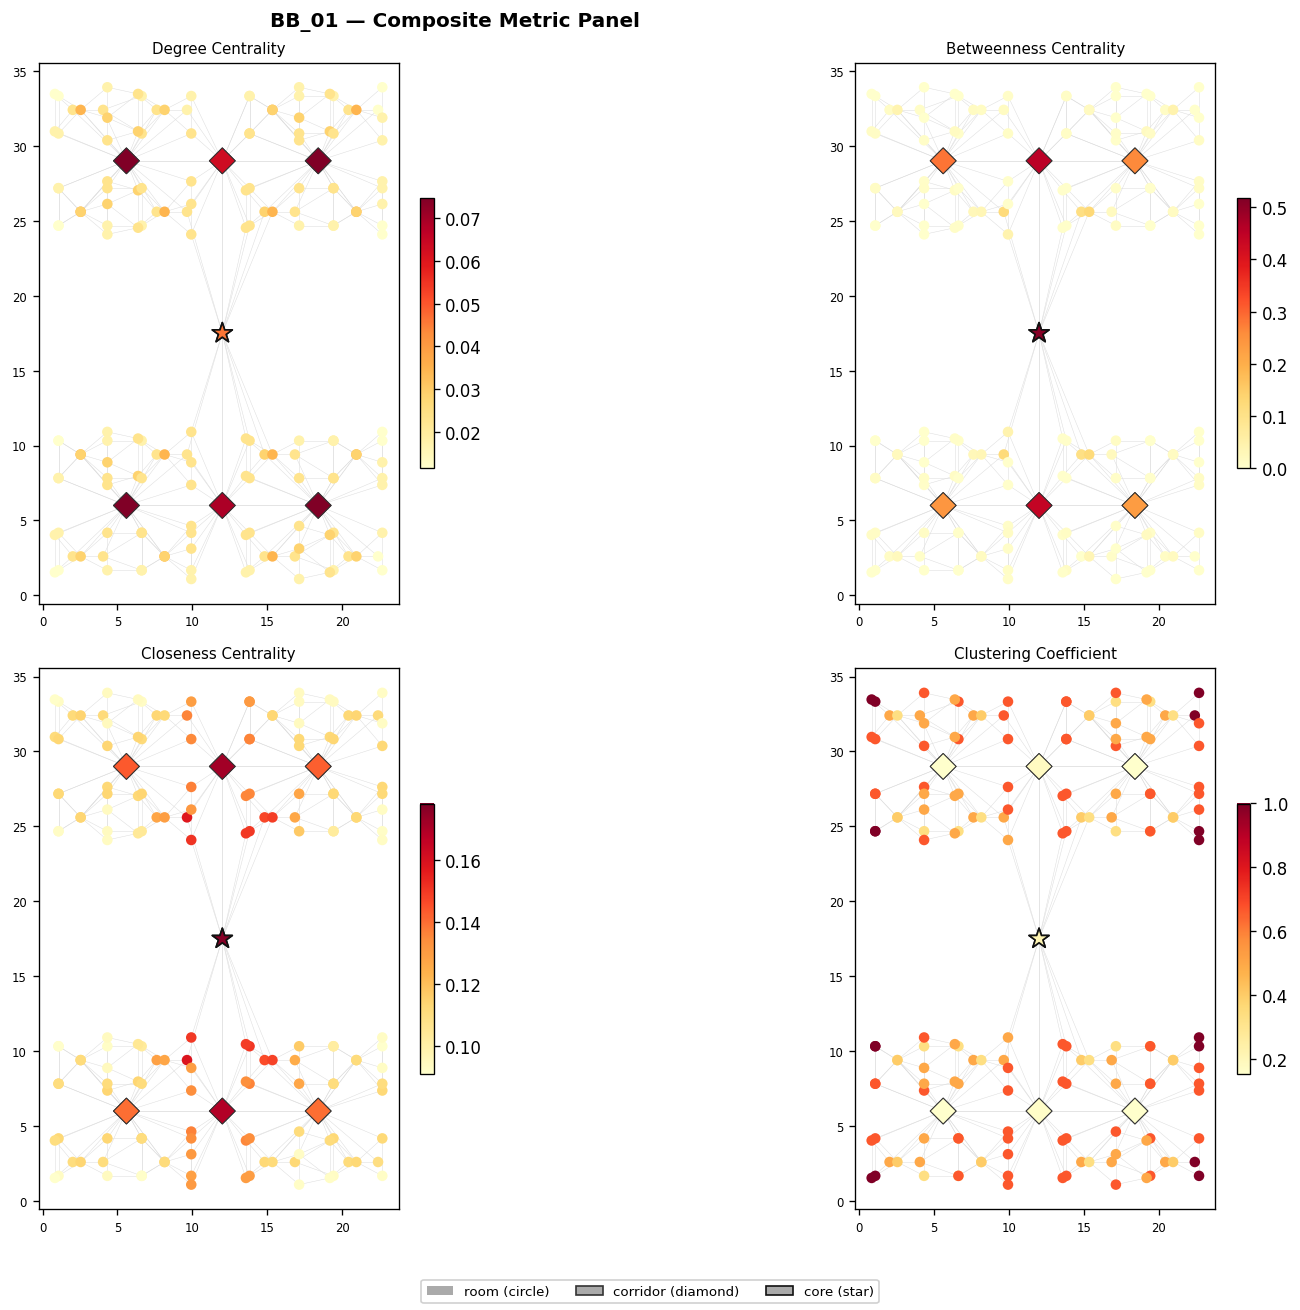

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_01\06_composite_metric_panel.png


In [24]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'

ROLE_MARKER = {'room': 'o', 'corridor': 'D', 'core': '*'}
ROLE_SIZE   = {'room': 40,  'corridor': 120, 'core': 160}
ROLE_EW     = {'room': 0.0, 'corridor': 0.6, 'core': 1.0}
ROLE_EC     = {'room': 'none', 'corridor': '#333333', 'core': '#111111'}
METRIC_CMAP = plt.cm.YlOrRd


def panel_scatter(ax, metric_col, title):
    _vals = metrics[metric_col].values.astype(float)
    _norm = Normalize(vmin=_vals.min(), vmax=max(_vals.max(), 1e-9))
    _node_metric = dict(zip(metrics['node_id'].astype(int), _vals))

    for _u, _v in G.edges():
        _x0, _y0 = POS_XY.get(_u, (0, 0))
        _x1, _y1 = POS_XY.get(_v, (0, 0))
        ax.plot([_x0, _x1], [_y0, _y1], color='#DDDDDD', lw=0.3, zorder=1)

    for _role in ('room', 'corridor', 'core'):
        _sub = metrics[metrics['node_role'] == _role]
        _ids = _sub['node_id'].astype(int).tolist()
        _xs  = [POS_XY[n][0] for n in _ids if n in POS_XY]
        _ys  = [POS_XY[n][1] for n in _ids if n in POS_XY]
        _cs  = [METRIC_CMAP(_norm(_node_metric.get(n, 0.0))) for n in _ids if n in POS_XY]
        ax.scatter(_xs, _ys, c=_cs, s=ROLE_SIZE[_role],
                   marker=ROLE_MARKER[_role],
                   edgecolors=ROLE_EC[_role],
                   linewidths=ROLE_EW[_role], zorder=3)

    _sm = plt.cm.ScalarMappable(cmap=METRIC_CMAP, norm=_norm)
    _sm.set_array([])
    plt.colorbar(_sm, ax=ax, shrink=0.5, pad=0.02)
    ax.set_title(title, fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=7)


_fig, _axes = plt.subplots(2, 2, figsize=(16, 11))
_fig.suptitle(f'{LAYOUT_ID} — Composite Metric Panel', fontsize=12, fontweight='bold')

_panel_specs = [
    ('degree_cent', 'Degree Centrality'),
    ('betweenness', 'Betweenness Centrality'),
    ('closeness',   'Closeness Centrality'),
    ('clustering',  'Clustering Coefficient'),
]
for _ax, (_col, _title) in zip(_axes.flat, _panel_specs):
    panel_scatter(_ax, _col, _title)

_fig.legend(
    handles=[
        mpatches.Patch(facecolor='#AAAAAA', edgecolor='none',    label='room (circle)'),
        mpatches.Patch(facecolor='#AAAAAA', edgecolor='#333333', label='corridor (diamond)'),
        mpatches.Patch(facecolor='#AAAAAA', edgecolor='#111111', label='core (star)'),
    ],
    loc='lower center', ncol=3, fontsize=8, framealpha=0.9,
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
_out = os.path.join(VISUALS_DIR, '06_composite_metric_panel.png')
_fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_out}')

---
## 4. Metrics by Node Role (Figure 07)

Box plots of all four metrics, grouped by `node_role`.  
Reveals whether corridors genuinely score higher on betweenness/closeness,
as expected in a double-loaded corridor typology.

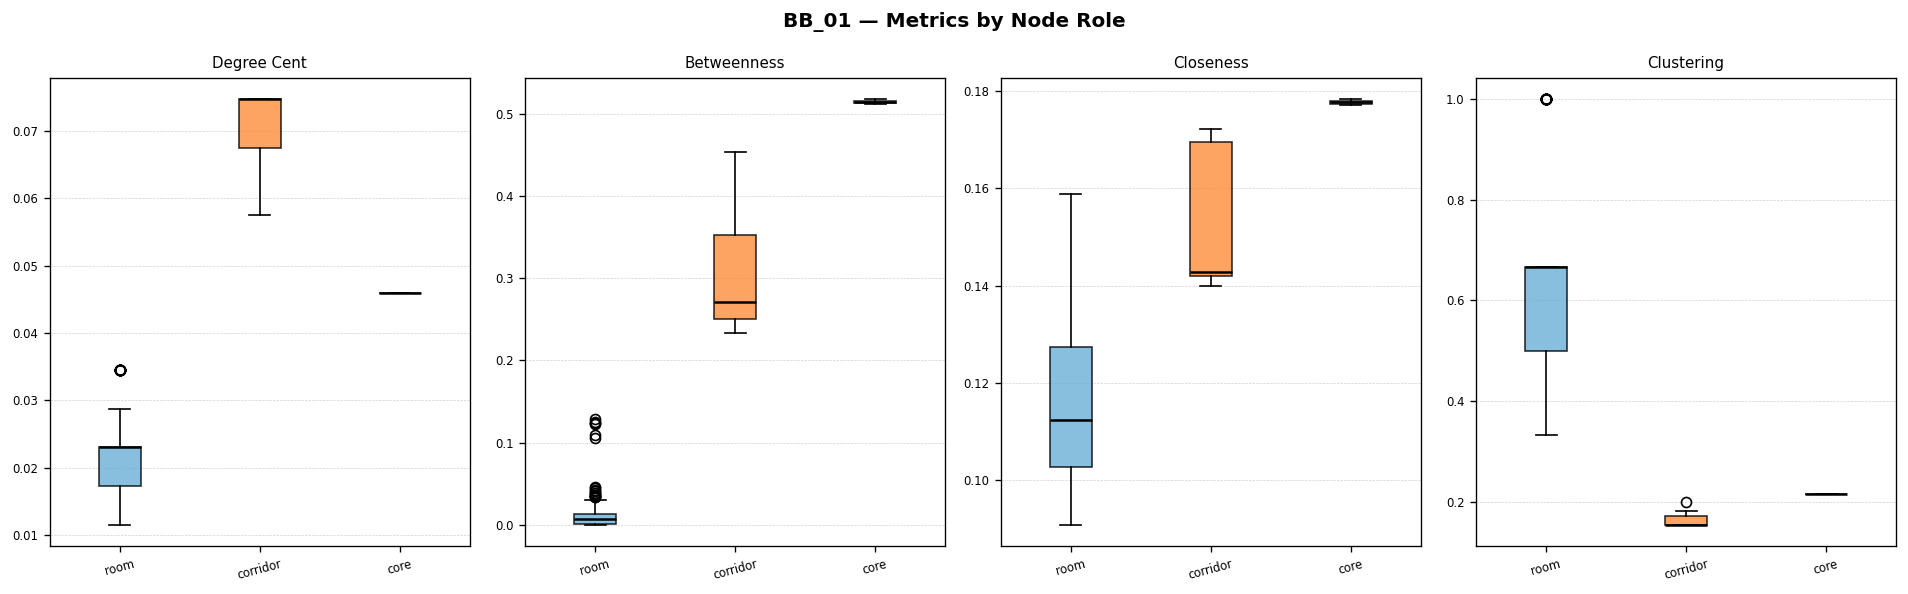

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_01\07_metrics_by_role.png

Median values by node_role:
           degree_cent  betweenness  closeness  clustering
node_role                                                 
core           0.04598      0.51452    0.17769     0.21429
corridor       0.07471      0.27062    0.14286     0.15385
room           0.02299      0.00666    0.11245     0.66667


In [25]:
_roles_order = ['room', 'corridor', 'core']
_ROLE_COLORS = {'room': '#6BAED6', 'corridor': '#FD8D3C', 'core': '#74C476'}

_fig, _axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
_fig.suptitle(f'{LAYOUT_ID} — Metrics by Node Role', fontsize=12, fontweight='bold')

for _ax, _col in zip(_axes, METRIC_COLS):
    _data  = [metrics[metrics['node_role'] == _r][_col].dropna().values
               for _r in _roles_order]
    _bp = _ax.boxplot(_data, patch_artist=True, medianprops={'color': 'black', 'lw': 1.5})
    for _patch, _role in zip(_bp['boxes'], _roles_order):
        _patch.set_facecolor(_ROLE_COLORS[_role])
        _patch.set_alpha(0.8)
    _ax.set_xticks(range(1, len(_roles_order) + 1))
    _ax.set_xticklabels(_roles_order, fontsize=8, rotation=15)
    _ax.set_title(_col.replace('_', ' ').title(), fontsize=9)
    _ax.tick_params(labelsize=7)
    _ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.6)

plt.tight_layout()
_out = os.path.join(VISUALS_DIR, '07_metrics_by_role.png')
_fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_out}')

print()
print('Median values by node_role:')
print(metrics.groupby('node_role')[METRIC_COLS].median().round(5).to_string())

---
## 5. Per-Floor Metric Profile (Figure 08)

Mean metric value per `physical_floor`, grouped by node role.  
In a symmetric building (identical floor plans stacked), values should be nearly equal
across floors — divergence reveals floor-level anomalies.

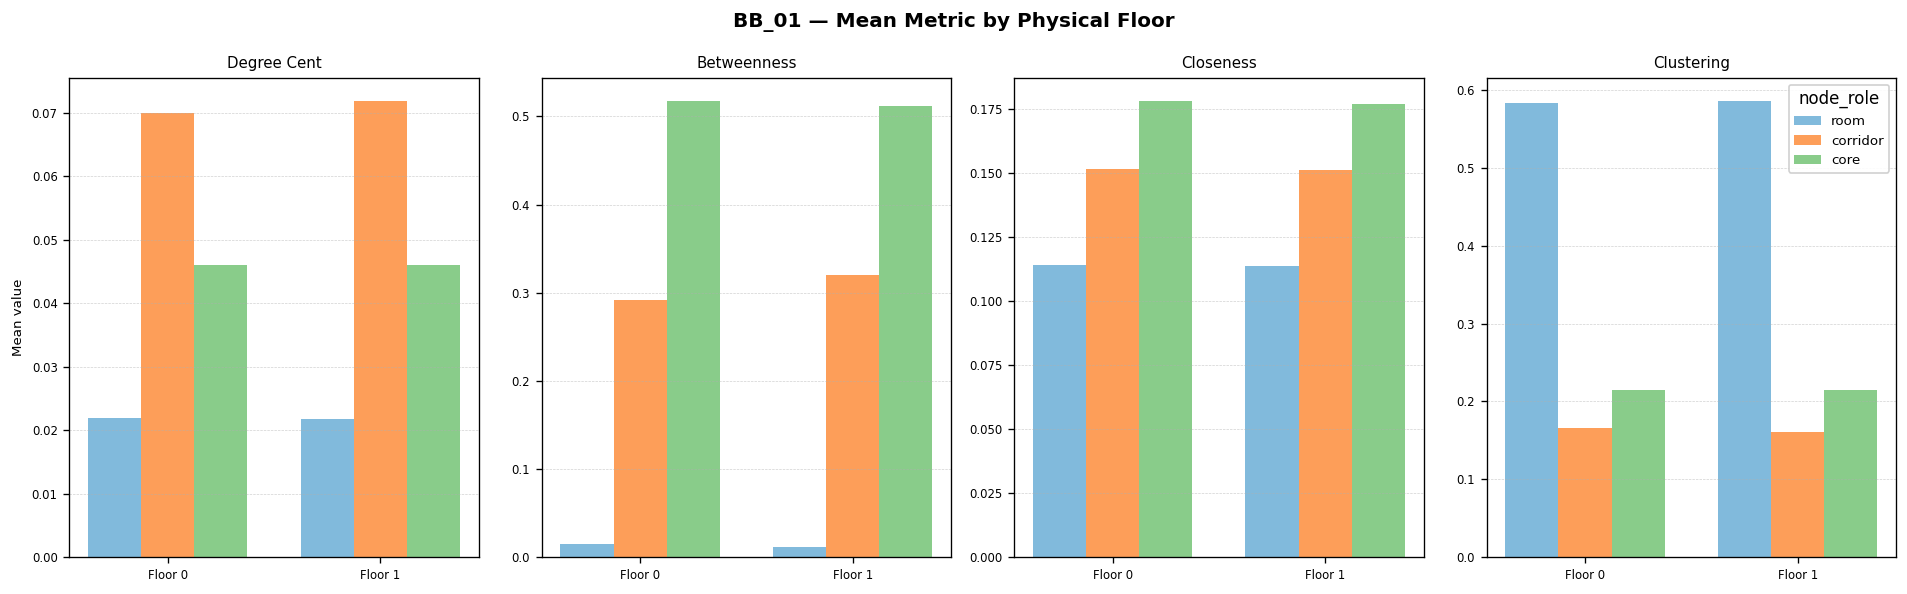

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_01\08_floor_metric_profile.png


In [26]:
_floors_sorted = sorted(metrics[PF_COL].dropna().unique())
_n_floors      = len(_floors_sorted)
_n_metrics     = len(METRIC_COLS)

_fig, _axes = plt.subplots(1, _n_metrics, figsize=(16, 5), sharey=False)
_fig.suptitle(f'{LAYOUT_ID} — Mean Metric by Physical Floor', fontsize=12, fontweight='bold')

_bar_width  = 0.25
_role_offsets = {'room': -_bar_width, 'corridor': 0.0, 'core': _bar_width}

for _ax, _col in zip(_axes, METRIC_COLS):
    _x = np.arange(_n_floors)
    for _role in ('room', 'corridor', 'core'):
        _means = [
            metrics[(metrics[PF_COL] == _f) & (metrics['node_role'] == _role)][_col].mean()
            for _f in _floors_sorted
        ]
        _ax.bar(_x + _role_offsets[_role], _means, _bar_width,
                label=_role, color=_ROLE_COLORS[_role], alpha=0.85)

    _ax.set_xticks(_x)
    _ax.set_xticklabels([f'Floor {int(f)}' for f in _floors_sorted], fontsize=8)
    _ax.set_title(_col.replace('_', ' ').title(), fontsize=9)
    _ax.tick_params(labelsize=7)
    _ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.6)

_axes[0].set_ylabel('Mean value', fontsize=8)
_axes[-1].legend(fontsize=8, framealpha=0.9, title='node_role', loc='upper right')
plt.tight_layout()
_out = os.path.join(VISUALS_DIR, '08_floor_metric_profile.png')
_fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_out}')

---
## 6. Metric Correlation Matrix (Figure 09)

Pearson correlations among the four centrality metrics.  
A high betweenness–closeness correlation suggests that the most reachable nodes are
also the most critical bottlenecks — common in linear double-loaded corridors.

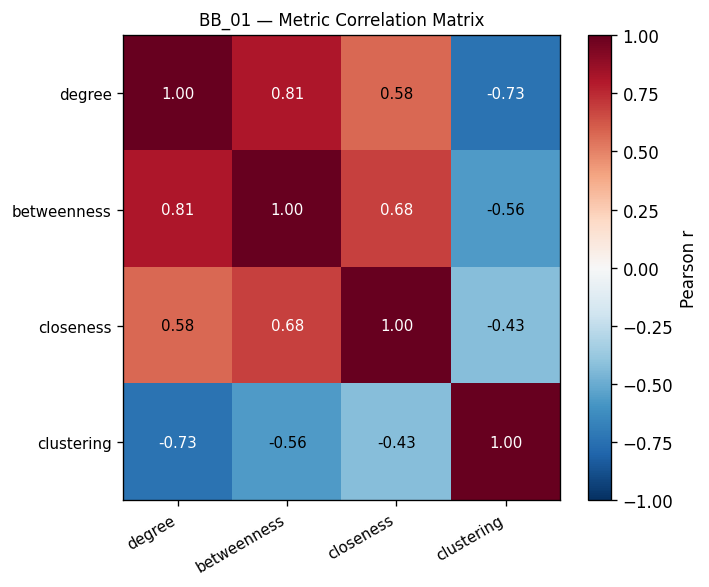

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_01\09_metric_correlation.png

Correlation matrix:
             degree_cent  betweenness  closeness  clustering
degree_cent       1.0000       0.8102     0.5764     -0.7345
betweenness       0.8102       1.0000     0.6827     -0.5639
closeness         0.5764       0.6827     1.0000     -0.4272
clustering       -0.7345      -0.5639    -0.4272      1.0000


In [27]:
_corr_labels = ['degree_cent', 'betweenness', 'closeness', 'clustering']
_corr        = metrics[_corr_labels].corr()

_fig, _ax = plt.subplots(figsize=(6, 5))
_im = _ax.imshow(_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(_im, ax=_ax, label='Pearson r')

_ax.set_xticks(range(len(_corr_labels)))
_ax.set_yticks(range(len(_corr_labels)))
_short = [l.replace('_cent', '').replace('_', ' ') for l in _corr_labels]
_ax.set_xticklabels(_short, fontsize=9, rotation=30, ha='right')
_ax.set_yticklabels(_short, fontsize=9)

for _i in range(len(_corr_labels)):
    for _j in range(len(_corr_labels)):
        _v = _corr.values[_i, _j]
        _txt_col = 'white' if abs(_v) > 0.6 else 'black'
        _ax.text(_j, _i, f'{_v:.2f}', ha='center', va='center',
                 fontsize=9, color=_txt_col)

_ax.set_title(f'{LAYOUT_ID} — Metric Correlation Matrix', fontsize=10)
plt.tight_layout()
_out = os.path.join(VISUALS_DIR, '09_metric_correlation.png')
_fig.savefig(_out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {_out}')
print()
print('Correlation matrix:')
print(_corr.round(4).to_string())

---
## 7. Spatial Interpretation Export

Generates `04_submission_text/{LAYOUT_ID}/interpretation.md` with a structured scaffold.
Replace every `[YOUR ANALYSIS]` marker with your observations before submitting.

The nine required sections are:
1. Graph Overview  
2. Degree Centrality  
3. Betweenness Centrality  
4. Closeness Centrality  
5. Clustering Coefficient  
6. Community Detection  
7. Component and Cross-Floor Limitations  
8. Architectural Findings  
9. Adjacency-Threshold Limitation

In [28]:
# Gather values for the template
_gs        = graph_sum.iloc[0]
_n_nodes   = int(_gs['n_nodes'])
_n_edges   = int(_gs['n_edges'])
_density   = float(_gs['density'])
_n_comp    = int(_gs['n_components'])
_n_comm    = int(_gs['n_communities'])
_avg_clust = float(_gs['avg_clustering'])

_comp_lines = []
for _, _r in comp_sum.iterrows():
    _comp_lines.append(
        f'  - Component {int(_r["component_id"])}: '
        f'{int(_r["n_nodes"])} nodes  '
        f'rooms={int(_r["rooms"])} corridors={int(_r["corridors"])} cores={int(_r["cores"])}  '
        f'diameter={int(_r["diameter"])}  avg_path={float(_r["avg_path_len"]):.3f}  '
        f'floors={_r["physical_floors"]}'
    )
_comp_block = '\n'.join(_comp_lines)

_mean_dc  = metrics['degree_cent'].mean()
_mean_bc  = metrics['betweenness'].mean()
_mean_cc  = metrics['closeness'].mean()
_mean_cl  = metrics['clustering'].mean()
_max_dc   = metrics['degree_cent'].max()
_max_bc   = metrics['betweenness'].max()
_max_cc   = metrics['closeness'].max()

_top_dc_id = metrics.loc[metrics['degree_cent'].idxmax(), 'node_id']
_top_bc_id = metrics.loc[metrics['betweenness'].idxmax(), 'node_id']
_top_cc_id = metrics.loc[metrics['closeness'].idxmax(), 'node_id']

_corr_bc_cc = float(_corr.loc['betweenness', 'closeness'])
_corr_dc_cl = float(_corr.loc['degree_cent', 'clustering'])

# --- Write line by line to avoid JSON encoding issues with triple-quoted strings ---
_out_md = os.path.join(SUBMISSION, 'interpretation.md')

_lines = [
    f'# Assignment 2 — Spatial Interpretation',
    f'## Layout: {LAYOUT_ID}  |  Two-Bars Residential Study',
    f'',
    f'> Scaffold generated by A2_02_TwoBars_Spatial_Interpretation.ipynb.',
    f'> Replace every `[YOUR ANALYSIS]` marker with your interpretation.',
    f'',
    f'---',
    f'',
    f'## 1. Graph Overview',
    f'',
    f'**Computed values:**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Nodes | {_n_nodes} |',
    f'| Edges | {_n_edges} |',
    f'| Density | {_density:.6f} |',
    f'| Connected components | {_n_comp} |',
    f'| Global avg clustering | {_avg_clust:.4f} |',
    f'| Communities detected | {_n_comm} |',
    f'',
    f'**Component breakdown:**',
    f'',
    _comp_block,
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- How does the density compare to a fully connected grid?',
    f'- What does the component count tell us about vertical connectivity?',
    f'',
    f'---',
    f'',
    f'## 2. Degree Centrality',
    f'',
    f'**Computed values:**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Mean degree centrality | {_mean_dc:.5f} |',
    f'| Max degree centrality | {_max_dc:.5f} (node {int(_top_dc_id)}) |',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- Which spatial roles (room / corridor / core) scored highest?',
    f'- Does the plan geometry explain these scores?',
    f'',
    f'---',
    f'',
    f'## 3. Betweenness Centrality',
    f'',
    f'**Computed values:**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Mean betweenness | {_mean_bc:.6f} |',
    f'| Max betweenness | {_max_bc:.6f} (node {int(_top_bc_id)}) |',
    f'| Betweenness-closeness correlation | {_corr_bc_cc:.4f} |',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- Where are the bottleneck rooms or corridors?',
    f'- How would removing the highest-betweenness node affect circulation?',
    f'',
    f'---',
    f'',
    f'## 4. Closeness Centrality',
    f'',
    f'**Computed values (Wasserman-Faust normalization):**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Mean closeness | {_mean_cc:.5f} |',
    f'| Max closeness | {_max_cc:.5f} (node {int(_top_cc_id)}) |',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- Are high-closeness nodes spatially central or corridor-adjacent?',
    f'- Compare to betweenness: do the same nodes score high on both?',
    f'',
    f'---',
    f'',
    f'## 5. Clustering Coefficient',
    f'',
    f'**Computed values:**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Global average clustering | {_avg_clust:.4f} |',
    f'| Mean clustering | {_mean_cl:.4f} |',
    f'| Degree-clustering correlation | {_corr_dc_cl:.4f} |',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- Which space types form tight local triangles?',
    f'- Does the corridor act as a low-clustering hub, as expected?',
    f'',
    f'---',
    f'',
    f'## 6. Community Detection',
    f'',
    f'**Computed values (Louvain algorithm):**',
    f'',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Communities detected | {_n_comm} |',
    f'| Physical floors | {_n_comp} |',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested prompts:',
    f'- Do detected communities align with individual apartments?',
    f'- Are corridor or core nodes split across multiple communities?',
    f'',
    f'---',
    f'',
    f'## 7. Component and Cross-Floor Limitations',
    f'',
    f'This dataset contains **{_n_comp} disconnected component(s)**, one per physical floor.',
    f'',
    f'**Why floors are disconnected:**  ',
    f'The Assignment 1 graph generation exported only horizontal (bbox) spatial adjacencies.',
    f'Stair and lift cells are present as `core` nodes but share no vertical edges with',
    f'equivalent nodes on adjacent floors. This is a modelling boundary, not a building defect.',
    f'',
    f'**Implications for metric interpretation:**',
    f'',
    f'- Betweenness and diameter were computed **per component** to avoid cross-component distortion.',
    f'- Closeness uses Wasserman-Faust normalization, which scales each node by its reachable fraction.',
    f'- All results in sections 2–6 describe **within-floor** spatial relationships only.',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'---',
    f'',
    f'## 8. Architectural Findings',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'Suggested structure:',
    f'- **Typological observation:** What metric pattern is characteristic of double-loaded corridors?',
    f'- **Design strength:** Which spatial quality does the metric data confirm?',
    f'- **Potential redesign:** Which metric reveals a spatial quality worth improving?',
    f'',
    f'---',
    f'',
    f'## 9. Adjacency-Threshold Limitation',
    f'',
    f'The edges in this graph are derived from **bounding-box spatial adjacency**',
    f'(gap threshold: 0.45 m), not from door aperture positions.',
    f'',
    f'**Implications:**',
    f'',
    f'- Two rooms sharing a wall are connected regardless of whether a door exists between them.',
    f'- The graph over-estimates accessibility between spaces that are adjacent but separated by',
    f'  solid walls (e.g., two apartments sharing a party wall).',
    f'- Centrality metrics in sections 2–5 reflect geometric proximity, not traversal through openings.',
    f'',
    f'**Your interpretation:** [YOUR ANALYSIS]',
    f'',
    f'---',
    f'',
    f'*End of interpretation scaffold — {LAYOUT_ID}*',
]

with open(_out_md, 'w', encoding='utf-8') as _f:
    for _line in _lines:
        _f.write(_line + '\n')

print(f'interpretation.md written: {_out_md}')
print(f'{len(_lines)} lines.')

interpretation.md written: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\05_submission_text\BB_01\interpretation.md
167 lines.


---
## 8. BB Layout Comparison (Optional)

This section activates automatically when `02_results/` folders exist for **2 or more**
Two-Bars layouts. When all three are present, a full comparison table and bar chart are produced.

The comparison shows how graph size, density, component count, and metric distributions
differ across the three Two-Bars typological variants.

BB layout result folders found: ['BB_01', 'BB_02', 'BB_03']

BB Layout Comparison:
layout_id  n_nodes  n_edges  density  n_components  n_communities  max_diameter  avg_clustering
    BB_01      175      388 0.025484             2              8             8         0.55118
    BB_02      381      858 0.011852             3             12             8         0.54872
    BB_03      141      303 0.030699             3             11             7         0.53894


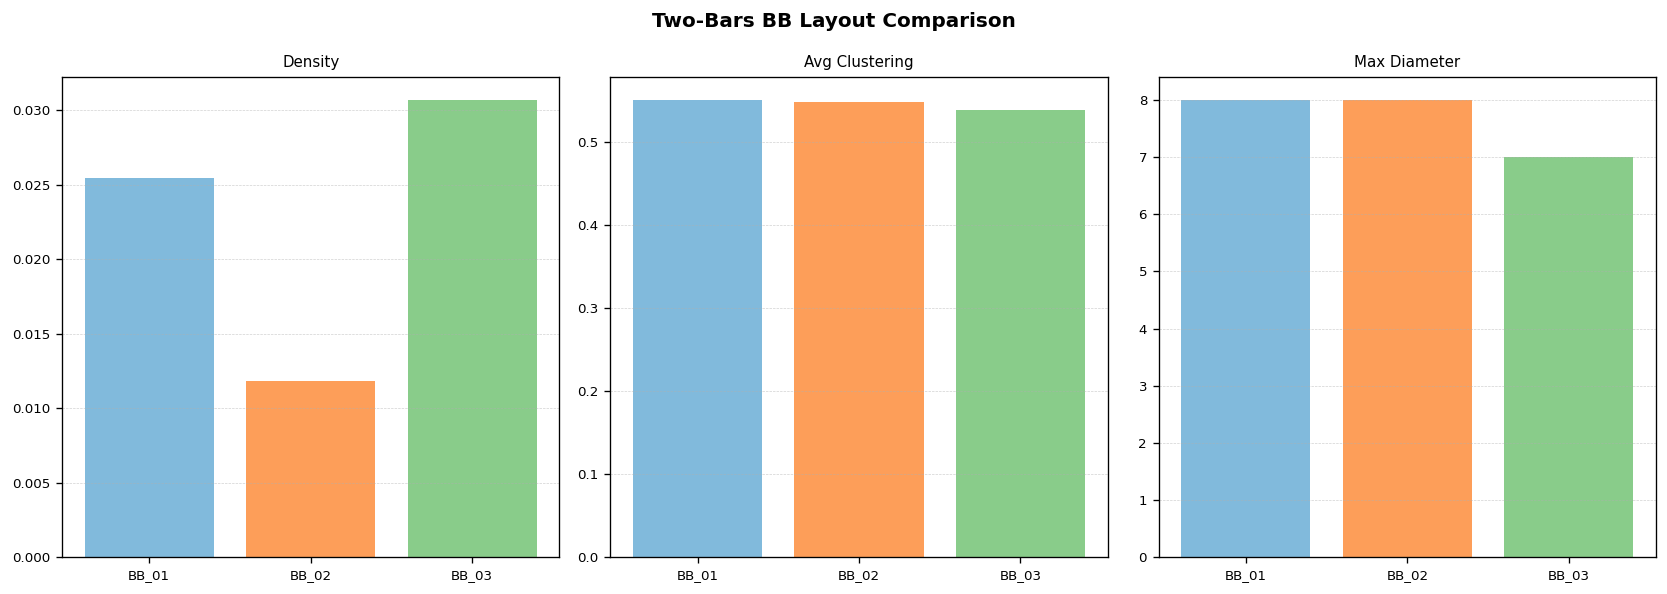

Saved: D:/GitHub/GML_Edu\assignments\assignment_02_graph_analysis\04_visuals\BB_comparison_overview.png


In [29]:
BB_LAYOUTS = ['BB_01', 'BB_02', 'BB_03']
_available = {
    _lid: os.path.join(A2_ROOT, '02_results', _lid, 'metrics_table.csv')
    for _lid in BB_LAYOUTS
}
_ready = {_lid: _p for _lid, _p in _available.items() if os.path.exists(_p)}

print(f'BB layout result folders found: {list(_ready.keys())}')

if len(_ready) < 2:
    print(f'Need results for at least 2 layouts to compare.')
    print(f'Missing: {[l for l in BB_LAYOUTS if l not in _ready]}')
    print('Run A2_01 for the missing layouts, then re-run this cell.')
else:
    # Load all available metric tables
    _all_metrics = {_lid: pd.read_csv(_p) for _lid, _p in _ready.items()}
    _all_graph   = {_lid: pd.read_csv(os.path.join(A2_ROOT, '02_results', _lid, 'graph_summary.csv'))
                    for _lid in _ready}
    _all_comp    = {_lid: pd.read_csv(os.path.join(A2_ROOT, '02_results', _lid, 'component_summary.csv'))
                    for _lid in _ready}

    # Build comparison table
    _comp_rows = []
    for _lid in sorted(_ready.keys()):
        _gs  = _all_graph[_lid].iloc[0]
        _mdf = _all_metrics[_lid]
        _row = {
            'layout_id'     : _lid,
            'n_nodes'       : int(_gs['n_nodes']),
            'n_edges'       : int(_gs['n_edges']),
            'density'       : round(float(_gs['density']), 6),
            'n_components'  : int(_gs['n_components']),
            'n_communities' : int(_gs['n_communities']),
            'avg_clustering': round(float(_gs['avg_clustering']), 5),
        }
        for _role in ('room', 'corridor', 'core'):
            _sub = _mdf[_mdf['node_role'] == _role]
            for _col in ('degree_cent', 'betweenness', 'closeness', 'clustering'):
                _row[f'{_role}_{_col}_mean'] = round(_sub[_col].mean(), 5)
        # Max diameter across components
        _cs = _all_comp[_lid]
        _row['max_diameter'] = int(_cs['diameter'].max())
        _comp_rows.append(_row)

    _cdf = pd.DataFrame(_comp_rows)
    _cdf.to_csv(os.path.join(A2_ROOT, '02_results', 'BB_comparison.csv'), index=False)
    print()
    print('BB Layout Comparison:')
    _disp_cols = ['layout_id', 'n_nodes', 'n_edges', 'density',
                  'n_components', 'n_communities', 'max_diameter', 'avg_clustering']
    print(_cdf[_disp_cols].to_string(index=False))

    # Bar chart comparison
    _comp_metric_cols = ['density', 'avg_clustering', 'max_diameter']
    _fig2, _axes2 = plt.subplots(1, len(_comp_metric_cols), figsize=(14, 5))
    _fig2.suptitle('Two-Bars BB Layout Comparison', fontsize=12, fontweight='bold')
    _lids  = _cdf['layout_id'].tolist()
    _cols3 = ['#6BAED6', '#FD8D3C', '#74C476'][:len(_lids)]

    for _ax2, _col2 in zip(_axes2, _comp_metric_cols):
        _vals2 = _cdf[_col2].tolist()
        _ax2.bar(_lids, _vals2, color=_cols3[:len(_vals2)], alpha=0.85)
        _ax2.set_title(_col2.replace('_', ' ').title(), fontsize=9)
        _ax2.tick_params(labelsize=8)
        _ax2.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.6)

    plt.tight_layout()
    _out_comp = os.path.join(A2_ROOT, '03_visuals', 'BB_comparison_overview.png')
    _fig2.savefig(_out_comp, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {_out_comp}')

---
## Verification

In [30]:
EXPECTED_OUTPUTS = [
    os.path.join(VISUALS_DIR, '06_composite_metric_panel.png'),
    os.path.join(VISUALS_DIR, '07_metrics_by_role.png'),
    os.path.join(VISUALS_DIR, '08_floor_metric_profile.png'),
    os.path.join(VISUALS_DIR, '09_metric_correlation.png'),
    os.path.join(SUBMISSION,  'interpretation.md'),
]

print(f'Output verification for {LAYOUT_ID}:')
_all_ok = True
for _path in EXPECTED_OUTPUTS:
    _ok = os.path.exists(_path)
    _all_ok = _all_ok and _ok
    print(f'  {"OK" if _ok else "MISSING":7s} {os.path.basename(_path)}')

print()
if _all_ok:
    print(f'All outputs present for {LAYOUT_ID}.')
    print(f'Edit interpretation.md to replace [YOUR ANALYSIS] markers before submitting.')
else:
    print('Some outputs missing. Check for errors in cells above.')

Output verification for BB_01:
  OK      06_composite_metric_panel.png
  OK      07_metrics_by_role.png
  OK      08_floor_metric_profile.png
  OK      09_metric_correlation.png
  OK      interpretation.md

All outputs present for BB_01.
Edit interpretation.md to replace [YOUR ANALYSIS] markers before submitting.
